# Pulse arrival times from the Crab pulsar
## Crab Pulsar Experiment Part 3.2

Use this notebook as a template for Part 3.2 of the Crab pulsar experiment.

In [ ]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np

# The interpolate library from scipy includes powerful interpolation routines
# including the Lagrange interpolation described in the lab script.
from scipy import interpolate

# Astropy provides many useful tools...
from astropy import coordinates as coord
from astropy import units as u
from astropy import constants as const
from astropy import time as astrotime

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from math import pi

## Load Data
Here we load your ToA data as well as the file containing solar system barycentre coordinates.

In [ ]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# A good test to do is if you can see the contents of the directory in which you work on your google drive.
# Here "My Drive" refers to the "root" of your google drive.
# By default your notebook should be in a directory called Colab Notebooks.
# This template assumes all files you want to read in are copied in the
# same directory. Note the slash at the end of the first line.

#==============================================================================================================
#pathcrabtemplate = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
pathcrabtemplate = rootpathdrive+'/'+'My Drive/Colab Notebooks/CrabPulsar/Crab_pulsar_template/' #Sara's directory
#==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathcrabtemplate):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.

['Dedispersion and data visualisation.ipynb', '.gitignore', 'README.md', 'LICENSE', 'template.txt', '20251007_100808_B0329+54.npz', '20251007_110422_B0950+08.npz', '20251007_121203_B1933+16.npz', '20251007_134605_B2021+51.npz', 'Searching for Pulsars.ipynb', '20251021_071206_B0531+21.npz', '20251021_102701_B1133+16.npz', '20251021_134059_B2020+28.npz', '20251021_071206_B0531+21.npz.toas.txt', '2025_ssb.txt', 'Make Time of Arrivals.ipynb', 'Crab Pulsar Timing.ipynb', '20251111_091248_B1133+16.npz', '20251111_054931_B0531+21.npz', '20251111_114643_B1929+10.npz', 'Another copy of Searching for Pulsars.ipynb']


In [ ]:
# Specify the file with ToAs you want to work on.
toafile  = os.path.join(pathcrabtemplate,"20251021_071206_B0531+21.npz.toas.txt")
baryfile = os.path.join(pathcrabtemplate,"2025_ssb.txt") # ssb_2022 will work for all of 2022.

# Read the barycentre file... Read the numpy loadtxt page to understand what this does...
year, month, day, xpos, ypos, zpos = np.loadtxt(baryfile,unpack=True)
year = year
month = month
day = day
xpos = xpos
ypos = ypos
zpos = zpos

print(year)
# @todo: Load in your ToAs in a similar way.
toa_day, toa_uncertainty = np.loadtxt(toafile,unpack=True)

[2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025.
 2025. 2025. 2025. 2025. 2025. 2025. 2025. 2025. 20

In [ ]:
print(toa_day)
#print(year, month, day)

[60969.30127305 60969.30347254 60969.30578723 60969.30810189
 60969.31041696 60969.31273162 60969.31504629 60969.31736087
 60969.31967599 60969.32199068 60969.32430547 60969.32662041
 60969.32893508 60969.33125014 60969.33356478 60969.33587947
 60969.33819453 60969.3405092  60969.3428239  60969.34513877
 60969.3474536  60969.34976866 60969.35115726]


In [ ]:
from astropy.time import Time

def ymd_to_mjd_array_astropy(year, month, day):
    """
    Convert year, month, day (0h UT) to Modified Julian Date (MJD) using Astropy.
    Supports scalar or NumPy array inputs.
    """
    # Create datetime strings in ISO format
    dates = [f"{int(y)}-{int(m):02d}-{int(d):02d}" for y, m, d in zip(year, month, day)]

    # Create Astropy Time object
    t = Time(dates, format='iso')

    # Return MJD
    return t.mjd

# Use Astropy for conversion
barycentre_mjd = ymd_to_mjd_array_astropy(year, month, day)

# Step 2: Apply the date window
lower_limit = 60968
upper_limit = 60971

measurement_mask = (barycentre_mjd >= lower_limit) & (barycentre_mjd <= upper_limit)

# Step 3: Filter all arrays
barycentre_mjd_new = barycentre_mjd[measurement_mask]
xpos_new = xpos[measurement_mask]
ypos_new = ypos[measurement_mask]
zpos_new = zpos[measurement_mask]

print(barycentre_mjd_new)

[60968. 60969. 60970. 60971.]


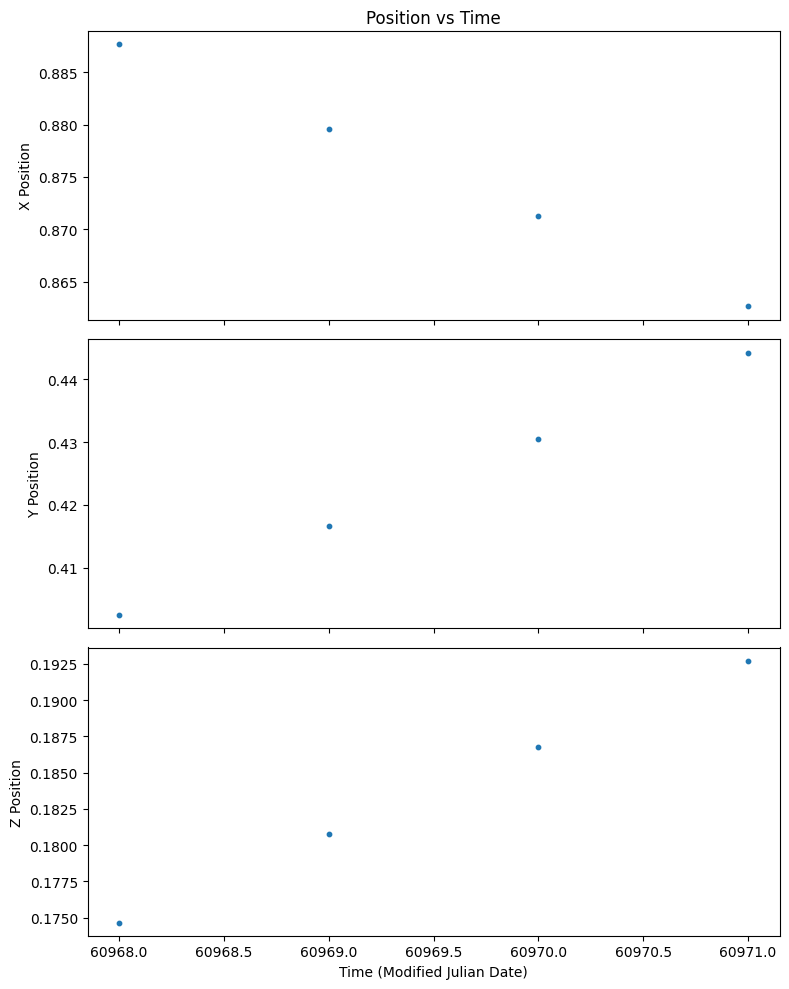

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

# X position
axes[0].scatter(barycentre_mjd_new, xpos_new, s=10)
axes[0].set_ylabel("X Position")
axes[0].set_title("Position vs Time")

# Y position
axes[1].scatter(barycentre_mjd_new, ypos_new, s=10)
axes[1].set_ylabel("Y Position")

# Z position
axes[2].scatter(barycentre_mjd_new, zpos_new, s=10)
axes[2].set_ylabel("Z Position")
axes[2].set_xlabel("Time (Modified Julian Date)")

plt.tight_layout()
plt.show()


## Interpolation
The Earth-barycentre vector is only given once per day (at 0 UT) in your input file. Therefore you will need to [interpolate](https://en.wikipedia.org/wiki/Interpolation) to get the vector at the time of each of your ToAs.

The below is an example code showing interpolation of a simple sinusoid function. Make sure you understand what this code is doing, then replace it with a function to interpolate your x, y and z positions at the times of your ToAs.

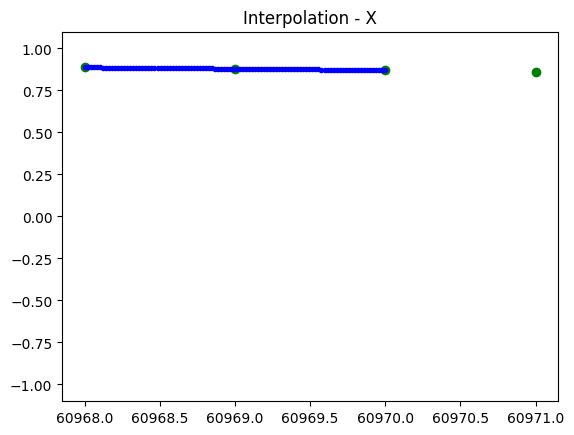

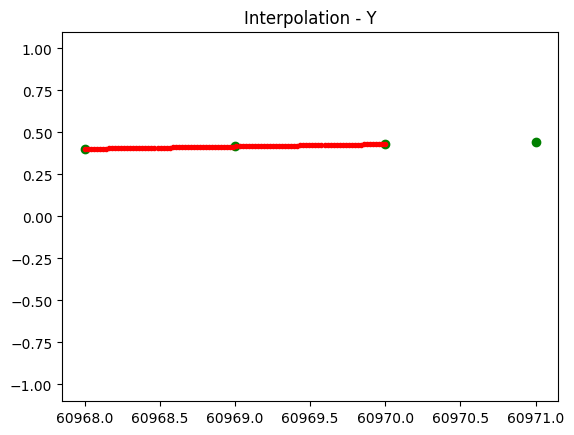

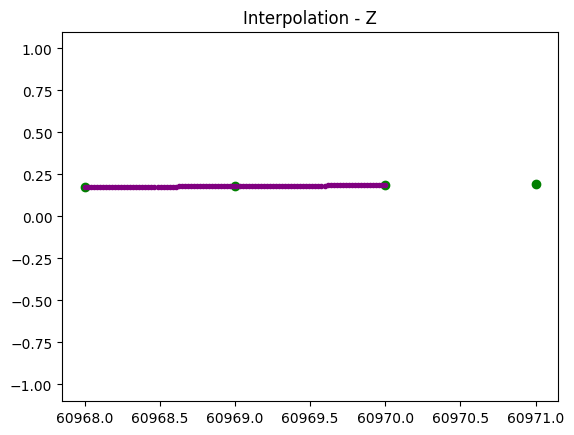

Interpolated coordinates at TOA days:
X positions: [0.87709309 0.87707484 0.87705563 0.87703642 0.87701721 0.876998
 0.87697879 0.87695958 0.87694036 0.87692114 0.87690193 0.8768827
 0.87686348 0.87684426 0.87682504 0.87680581 0.87678658 0.87676735
 0.87674813 0.87672889 0.87670966 0.87669042 0.87667889]
Y positions: [0.42078655 0.42081714 0.42084933 0.42088153 0.42091372 0.42094592
 0.42097811 0.4210103  0.42104249 0.42107468 0.42110687 0.42113907
 0.42117125 0.42120345 0.42123563 0.42126782 0.42130001 0.42133219
 0.42136438 0.42139656 0.42142874 0.42146093 0.42148024]
Z positions: [0.18255397 0.18256724 0.18258119 0.18259515 0.18260911 0.18262306
 0.18263702 0.18265097 0.18266493 0.18267889 0.18269284 0.1827068
 0.18272075 0.18273471 0.18274866 0.18276261 0.18277657 0.18279052
 0.18280447 0.18281842 0.18283238 0.18284633 0.1828547 ]


In [ ]:
# Interpolation Valyes
start_point = 0
interp_number=3

# For x coordinate
x = barycentre_mjd_new
y_x = xpos_new

interp_function_x = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_x[start_point:start_point+interp_number])

x2 = np.linspace(x[start_point], x[start_point + interp_number - 1], 100)
y2_x = interp_function_x(x2)

plt.plot(x, y_x, 'o', color='green')
plt.plot(x2, y2_x, '.', color='blue')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - X")
plt.show()

xpos_at_times = interp_function_x(toa_day)

# For y coordinate
y_y = ypos_new

interp_function_y = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_y[start_point:start_point+interp_number])

y2_y = interp_function_y(x2)

plt.plot(x, y_y, 'o', color='green')
plt.plot(x2, y2_y, '.', color='red')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - Y")
plt.show()

ypos_at_times = interp_function_y(toa_day)

# For z coordinate
y_z = zpos_new

interp_function_z = interpolate.lagrange(x[start_point:start_point+interp_number],\
                                        y_z[start_point:start_point+interp_number])

y2_z = interp_function_z(x2)

plt.plot(x, y_z, 'o', color='green')
plt.plot(x2, y2_z, '.', color='purple')
plt.ylim(-1.1, 1.1)
plt.title("Interpolation - Z")
plt.show()

zpos_at_times = interp_function_z(toa_day)

# Print or save all interpolated coordinates
print("Interpolated coordinates at TOA days:")
print(f"X positions: {xpos_at_times}")
print(f"Y positions: {ypos_at_times}")
print(f"Z positions: {zpos_at_times}")


coordinates_array = np.column_stack((xpos_at_times, ypos_at_times, zpos_at_times))

In [ ]:
# Example: check how well the interpolation predicts nearby actual data points
actual_values = ypos_new[start_point:start_point+interp_number+1]  # one more real point
predicted_values = interp_function_y(x[start_point:start_point+interp_number+1])
residuals = actual_values - predicted_values
error = np.sqrt(np.mean(residuals**2))  # RMS error
print("RMS interpolation error:", error)


RMS interpolation error: 2.340674442403175e-06


## Compute the Earth delay

This is the delay due to the fact that the observatory is not at the centre of the Earth. For this, you need to know the elevation angle above the horizon (see the lab script for more details).

The [Astropy](http://www.astropy.org/) library provides very powerful tools to do things like coordinate transforms. Here we want to convert from equitorial (RA and Dec) coordinate system to an observatory-based [AltAz](http://docs.astropy.org/en/stable/api/astropy.coordinates.AltAz.html) coordinate system. Make sure you are familiar with these two coordinate systems. The conversion from one to the other requries knowing the location of your telecsope and also the time the observations were taken.

The following libraries have been imported for your convinience:
 * ``astropy.coordinate`` has been imported as ``coord``
 * ``astropy.time`` has been imported as ``astrotime``


Altitudes (deg): [39d52m51.05420607s 39d25m36.59981193s 38d56m49.56070645s
 38d27m55.76552728s 37d58m55.28200149s 37d29m49.07119806s
 37d00m37.19996623s 36d31m20.08307031s 36d01m57.59750165s
 35d32m30.79975505s 35d02m59.63630038s 34d33m24.37438982s
 34d03m45.65783914s 33d34m03.28869638s 33d04m18.18516435s
 32d34m30.28243015s 32d04m39.62932761s 31d34m47.09575344s
 31d04m52.63687953s 30d34m56.40751223s 30d04m58.85194925s
 29d35m00.01830484s 29d17m00.63899634s]
Azimuths (deg): [252d26m43.70975389s 253d11m52.35115167s 253d58m56.76000843s
 254d45m35.18868246s 255d31m48.94620129s 256d17m37.89044491s
 257d03m03.27795356s 257d48m05.78317839s 258d32m46.87092523s
 259d17m06.1835643s 260d01m05.02784698s 260d44m44.19116768s
 261d28m03.88588063s 262d11m05.5317523s 262d53m48.9039907s
 263d36m15.17927193s 264d18m25.33571772s 265d00m19.17340005s
 265d41m57.7650461s 266d23m21.87563702s 267d04m31.85055175s
 267d45m28.56239308s 268d09m55.87900121s]


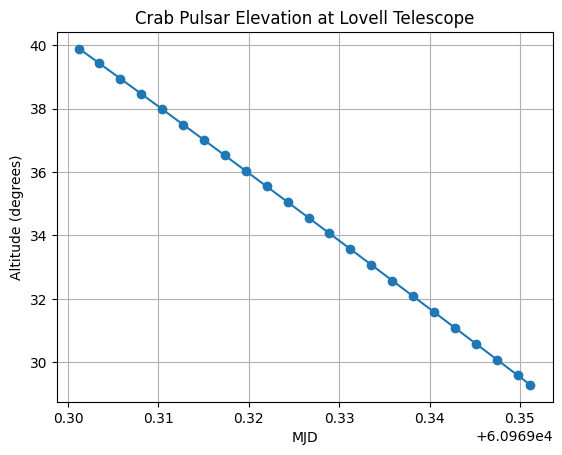

Earth delay (s): [0.01364142 0.01351162 0.01337355 0.013234   0.01309297 0.01295054
 0.01280671 0.01266152 0.01251497 0.01236714 0.01221804 0.01206769
 0.01191615 0.01176341 0.01160955 0.01145458 0.01129851 0.01114142
 0.01098332 0.01082424 0.01066421 0.01050326 0.0104063 ]


In [ ]:
from astropy import constants as const


# Crab Pulsar position
pulsarpos = coord.SkyCoord(ra="05:34:31.9", dec="+22:00:52.0",
                           unit=(u.hourangle, u.deg))

lovellpos = coord.EarthLocation(
    lat="53:14:09", lon="-2:18:23", height=126.3*u.m
)

times = Time(toa_day, format='mjd', scale='utc')

# Transform to AltAz
altaz = pulsarpos.transform_to(coord.AltAz(obstime=times, location=lovellpos))

# Check output
print("Altitudes (deg):", altaz.alt)
print("Azimuths (deg):", altaz.az)

# Optional plot
plt.plot(times.mjd, altaz.alt.deg, 'o-')
plt.xlabel("MJD")
plt.ylabel("Altitude (degrees)")
plt.title("Crab Pulsar Elevation at Lovell Telescope")
plt.grid(True)
plt.show()


# Get altitude in radians
elevation_rad = altaz.alt.to(u.rad).value  # numeric array in radians

# Constants
R_earth = const.R_earth.value  # meters
c = const.c.value              # m/s

# Compute Earth delay
earth_delay = (R_earth * np.sin(elevation_rad)) / c  # seconds

print("Earth delay (s):", earth_delay)


## Compute the Roemer delay

This is the delay corresponding to the distance of the centre of the Earth to the barycentre.
$$
\Delta_{Rsun} = \frac{1}{c} \vec{r}_{vec} \cdot \hat{\vec{s}} = -\frac{1}{c} \left( \vec{r}_{SSB} + \vec{r}_{EO} \right) \cdot \hat{\vec{s}}
$$


[272.6224866  272.63796685 272.65425602 272.67054311 272.68683106
 272.70311439 272.71939589 272.73567498 272.75195602 272.76823243
 272.78450771 272.80078241 272.81705358 272.83332583 272.84959358
 272.86586016 272.88212778 272.89839116 272.91465327 272.93091524
 272.9471755  272.96343604 272.97318866] s
Roemer delay (s) for each TOA:
[272.6224866  272.63796685 272.65425602 272.67054311 272.68683106
 272.70311439 272.71939589 272.73567498 272.75195602 272.76823243
 272.78450771 272.80078241 272.81705358 272.83332583 272.84959358
 272.86586016 272.88212778 272.89839116 272.91465327 272.93091524
 272.9471755  272.96343604 272.97318866] s


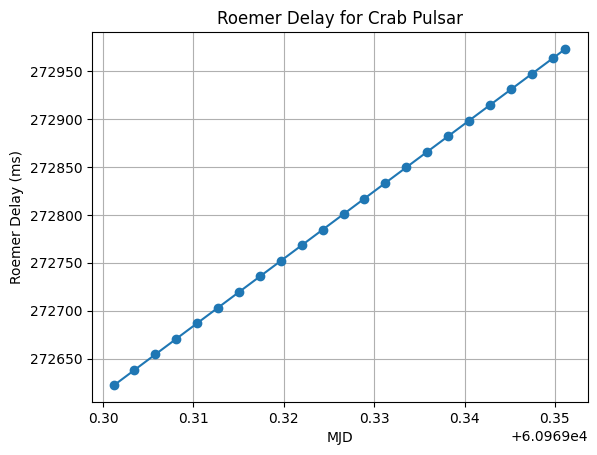

In [ ]:
c = const.c

# Barycentre positions at ToA and subsequently our observation coords (centre of earth)
psr_x = xpos_at_times
psr_y = ypos_at_times
psr_z = zpos_at_times
r_ssb = np.column_stack((xpos_at_times, ypos_at_times, zpos_at_times))  # Earth to barycentre vector at TOA

# Converting pulsar's RA and Dec coords into cartesian
pulsar_cart = pulsarpos.icrs.cartesian
s_hat = np.array([pulsar_cart.x.value,
                  pulsar_cart.y.value,
                  pulsar_cart.z.value])
s_hat /= np.linalg.norm(s_hat)  # ensure it's a unit vector

r_ssb_q = r_ssb * const.au  # corrected r_ssb in metres

# Fix: Add units to r_sine to make it consistent
r_sine = (R_earth * np.sin(elevation_rad)) * u.m  # Add units explicitly

# Calculate the dot product and ensure proper units
dot_product = np.dot(r_ssb_q, s_hat)  # This has units of meters

roemer_delay = (1/c) * (dot_product + r_sine)

print(roemer_delay)
print("Roemer delay (s) for each TOA:")
print(roemer_delay)

plt.plot(toa_day, roemer_delay.to(u.ms), 'o-')
plt.xlabel("MJD")
plt.ylabel("Roemer Delay (ms)")
plt.title("Roemer Delay for Crab Pulsar")
plt.grid(True)
plt.show()



In [ ]:
# Convert Time object to MJD values (plain numbers)
times_mjd = times.mjd  # This gives you the numerical MJD values

print("Times MJD values:", times_mjd)

# Convert Roemer delay from seconds to days (since MJD is in days)
roemer_delay_days = roemer_delay.to(u.day)

# Now add them properly
corrected_time_mjd = times_mjd + roemer_delay_days.value

print("Corrected times (MJD):", corrected_time_mjd)

# If you want to convert back to Time object:
corrected_time = Time(corrected_time_mjd, format='mjd')
print("Corrected Time objects:", corrected_time)

Times MJD values: [60969.30127305 60969.30347254 60969.30578723 60969.30810189
 60969.31041696 60969.31273162 60969.31504629 60969.31736087
 60969.31967599 60969.32199068 60969.32430547 60969.32662041
 60969.32893508 60969.33125014 60969.33356478 60969.33587947
 60969.33819453 60969.3405092  60969.3428239  60969.34513877
 60969.3474536  60969.34976866 60969.35115726]
Corrected times (MJD): [60969.30442841 60969.30662807 60969.30894295 60969.3112578
 60969.31357305 60969.31588791 60969.31820276 60969.32051753
 60969.32283284 60969.32514772 60969.3274627  60969.32977783
 60969.33209269 60969.33440793 60969.33672276 60969.33903764
 60969.34135289 60969.34366775 60969.34598263 60969.34829769
 60969.35061271 60969.35292796 60969.35431667]
Corrected Time objects: [60969.30442841 60969.30662807 60969.30894295 60969.3112578
 60969.31357305 60969.31588791 60969.31820276 60969.32051753
 60969.32283284 60969.32514772 60969.3274627  60969.32977783
 60969.33209269 60969.33440793 60969.33672276 6096

## Residuals from a fixed period model - WORKING PROGRESS



In [ ]:
# import numpy as np
# from astropy import units as u
# from astropy.time import Time
# import matplotlib.pyplot as plt


# corrected_time = Time(corrected_time_mjd, format='mjd')

# # Initial model period estimate (in seconds)
# period_guess = 0.033847063 * u.s

# # Reference (The first corrected TOA)
# t_0_mjd = corrected_time[0]

# # Calculate time difference (t - t0) in MJD days
# delta_t_days = corrected_time - t_0_mjd

# # Convert time difference to seconds
# delta_t_seconds = delta_t_days * u.day
# #time_elapsed = delta_t_seconds.to(u.s).value
# print(delta_t_seconds)

# # Calculate the EXPECTED number of rotations (N) based on the model
# # N = (t - t0) / P_model
# N = delta_t_seconds.to(u.s) / period_guess

# # Calculate the fractional part of N (the residual in PHASE)
# # fractional_part = N - floor(N)
# N_integer = np.floor(N.value)
# N_fraction = N.value - N_integer

# # Calculate the RESIDUAL in TIME (seconds)
# # Residual (dt) = fractional_part * P_model
# residuals = N_fraction * period_guess.value

# #  Linear fitting

# # Perform a linear fit (polynomial of degree 1) to the residuals vs. time
# # polyfit returns [m, c], where m is the slope and c is the y-intercept.
# # We fit Residuals (Y) vs. Time Elapsed (X)
# (slope_m, intercept_c) = np.polyfit(time_elapsed, residuals, 1)

# # --- 4. Final Period Correction ---

# # The correction needed is calculated from the slope: Delta_P = -m * P_model
# delta_p = -slope_m * period_guess.value

# # The new, more accurate period: P_new = P_model + Delta_P
# period_new = period_guess.value + delta_p



# #--- 5. Output Results ---

# print(f"--- Timing Residual Analysis ---")
# print(f"Reference Epoch (t0): {t_0_mjd:.9f} MJD")
# print(f"Initial Model Period (P_model): {period_guess.value:.9f} s")
# print("-" * 35)
# print(f"Slope of Residuals (m): {slope_m:.9e}")
# print(f"Period Correction (Delta P): {delta_p:.9e} s")
# print("-" * 35)
# print(f"New Accurate Period (P_new): {period_new:.10f} s")


# # --- 6. Plotting (Optional but highly recommended) ---
# # Create the best-fit line for plotting
# fit_line = slope_m * time_elapsed + intercept_c

# plt.figure(figsize=(10, 6))
# plt.plot(time_elapsed, residuals * 1000, 'o', label='Calculated Residuals')
# plt.plot(time_elapsed, fit_line * 1000, 'r-', label=f'Linear Fit (Slope = {slope_m:.2e})')
# plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

# plt.xlabel('Time Elapsed from $t_0$ (seconds)')
# plt.ylabel('Residuals (milliseconds)')
# plt.title(f'Crab Pulsar Timing Residuals $\\Delta P = {delta_p:.2e}$ s')
# plt.legend()
# plt.grid(True)
# plt.show()



In [ ]:
# import numpy as np
# from astropy import units as u
# from astropy.time import Time
# import matplotlib.pyplot as plt

# # Assuming corrected_time_mjd is defined somewhere
# # corrected_time_mjd = ... your data here ...

# corrected_time = Time(corrected_time_mjd, format='mjd')

# # Initial model period estimate (in seconds)
# period_guess = 0.033847063 * u.s

# # Reference (The first corrected TOA)
# t_0_mjd = corrected_time[0]

# # Calculate time difference (t - t0) in MJD days
# delta_t_days = corrected_time - t_0_mjd

# # Convert time difference to seconds
# delta_t_seconds = delta_t_days.to(u.s)  # FIXED: Use .to() method properly
# time_elapsed = delta_t_seconds.value    # FIXED: Extract numerical values

# print("Time elapsed (s):", time_elapsed)

# # Calculate the EXPECTED number of rotations (N) based on the model
# # N = (t - t0) / P_model
# N = delta_t_seconds / period_guess      # FIXED: Keep as Quantity

# # Calculate the fractional part of N (the residual in PHASE)
# # fractional_part = N - floor(N)
# N_integer = np.round(N.value)
# N_fraction = N.value - N_integer

# # Calculate the RESIDUAL in TIME (seconds)
# # Residual (dt) = fractional_part * P_model
# residuals = N_fraction * period_guess.value

# # Linear fitting

# # Perform a linear fit (polynomial of degree 1) to the residuals vs. time
# # polyfit returns [m, c], where m is the slope and c is the y-intercept.
# # We fit Residuals (Y) vs. Time Elapsed (X)
# (slope_m, intercept_c) = np.polyfit(time_elapsed, residuals, 1)

# # --- 4. Final Period Correction ---

# # The correction needed is calculated from the slope: Delta_P = -m * P_model
# delta_p = -slope_m * period_guess.value

# # The new, more accurate period: P_new = P_model + Delta_P
# period_new = period_guess.value + delta_p

# # --- 5. Output Results ---

# print(f"--- Timing Residual Analysis ---")
# print(f"Reference Epoch (t0): {t_0_mjd.mjd:.9f} MJD")  # FIXED: Access MJD value
# print(f"Initial Model Period (P_model): {period_guess.value:.9f} s")
# print("-" * 35)
# print(f"Slope of Residuals (m): {slope_m:.9e}")
# print(f"Period Correction (Delta P): {delta_p:.9e} s")
# print("-" * 35)
# print(f"New Accurate Period (P_new): {period_new:.10f} s")

# # --- 6. Plotting (Optional but highly recommended) ---
# # Create the best-fit line for plotting
# fit_line = slope_m * time_elapsed + intercept_c

# plt.figure(figsize=(10, 6))
# plt.plot(time_elapsed, residuals * 1000, 'o', label='Calculated Residuals')
# plt.plot(time_elapsed, fit_line * 1000, 'r-', label=f'Linear Fit (Slope = {slope_m:.2e})')
# plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

# plt.xlabel('Time Elapsed from $t_0$ (seconds)')
# plt.ylabel('Residuals (milliseconds)')
# plt.title(f'Crab Pulsar Timing Residuals $\\Delta P = {delta_p:.2e}$ s')
# plt.legend()
# plt.grid(True)
# plt.show()

Time elapsed (s): [   0.          190.05095128  390.05630629  590.05985961  790.09737221
  990.10091359 1190.10436067 1390.10063808 1590.14276932 1790.1489862
 1990.16269022 2190.18994651 2390.19370163 2590.23082447 2790.232126
 2990.23806187 3190.27551035 3390.27905173 3590.28487257 3790.30622465
 3990.32359428 4190.36106225 4310.34584383]
N: [     0.           5614.9909159   11524.08131502  17433.11848382
  23343.15896805  29252.19578396  35161.22981391  41070.05201838
  46980.22895871  52889.34482146  58798.68188908  64708.41935422
  70617.46248496  76527.49145391  82436.46209409  88345.56965469
  94255.60824447 100164.64506038 106073.74922212 111983.3122493
 117892.75761629 123802.79678184 127347.70647102]
N_integer: [     0.   5615.  11524.  17433.  23343.  29252.  35161.  41070.  46980.
  52889.  58799.  64708.  70617.  76527.  82436.  88346.  94256. 100165.
 106074. 111983. 117893. 123803. 127348.]
residuals [ 0.         -0.00030747  0.00275227  0.00401033  0.0053806   0.0066267

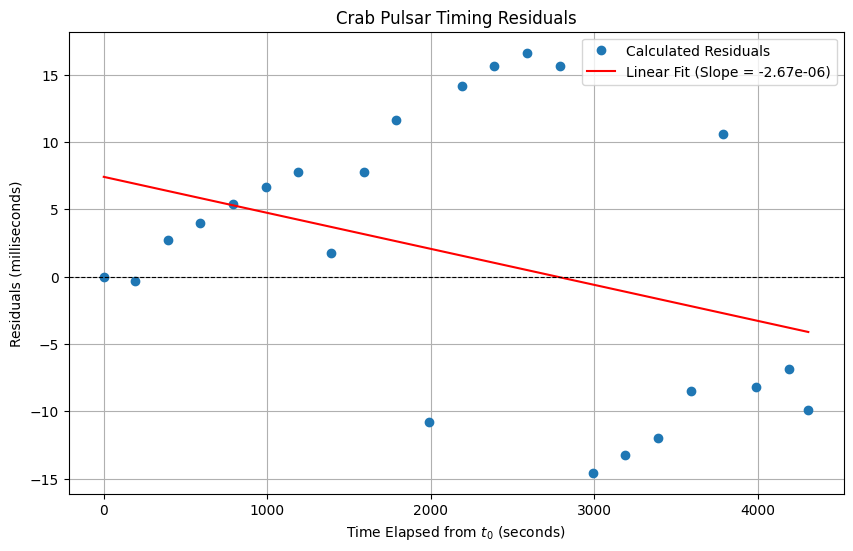

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 0.0013975176159563981
        x: [ 3.227e-02]
      nit: 1
      jac: [ 2.186e+03]
 hess_inv: [[ 1.076e-09]]
     nfev: 113
     njev: 51


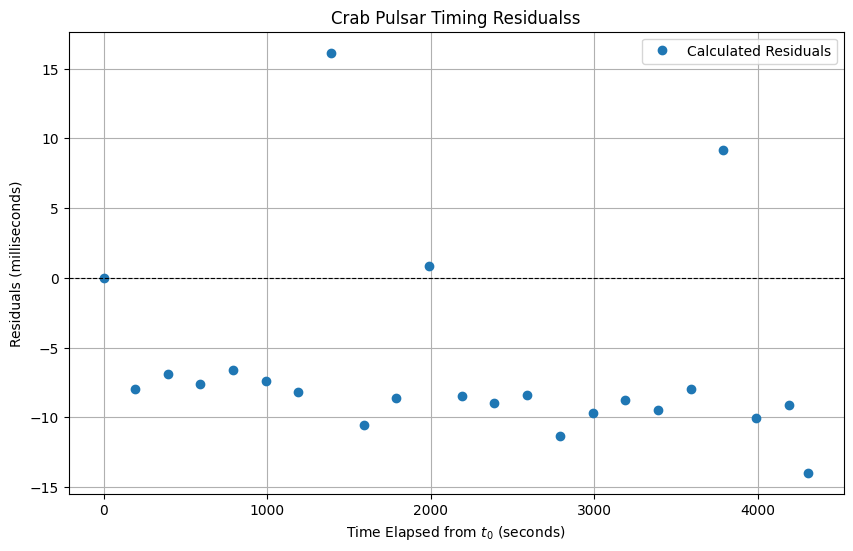

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
# Constants
SECONDS_PER_DAY = 86400.0

# Initial model period estimate (in seconds)
period_guess = 0.033847063  # seconds

# Reference (The first corrected TOA)
t_0_mjd = corrected_time_mjd[0]

# Calculate time difference (t - t0) in MJD days
delta_t_days = corrected_time_mjd - t_0_mjd

# Convert time difference to seconds
delta_t_seconds = delta_t_days * SECONDS_PER_DAY
time_elapsed = delta_t_seconds

print("Time elapsed (s):", time_elapsed)

# Calculate the EXPECTED number of rotations (N) based on the model
# N = (t - t0) / P_model
N = delta_t_seconds / period_guess
print("N:", N)
# Calculate the fractional part of N (the residual in PHASE)
# fractional_part = N - floor(N)
N_integer = np.round(N)
print("N_integer:", N_integer)


N_fraction = N - N_integer

# Calculate the RESIDUAL in TIME (seconds)
# Residual (dt) = fractional_part * P_model
residuals = N_fraction * period_guess
print("residuals", residuals)
# Linear fitting

# Perform a linear fit (polynomial of degree 1) to the residuals vs. time
# polyfit returns [m, c], where m is the slope and c is the y-intercept.
# We fit Residuals (Y) vs. Time Elapsed (X)
(slope_m, intercept_c) = np.polyfit(time_elapsed, residuals, 1)

###
def residual_calc(period_guess):
      N = delta_t_seconds / period_guess
      N_int = np.round(N)
      frac = N - N_int
      return frac * period_guess

def chisqfunc(period_guess):
     res = residual_calc(period_guess)
     return np.sum((res)**2)

x0 = np.array([period_guess])
result =  opt.minimize(chisqfunc, x0)
print(result)

print(time_elapsed)
#     chisq = numpy.sum((((model-N_integer)/toa_err))**2)
#     return chisq

# x0 = numpy.array([0,0])

# result =  opt.minimize(chisqfunc, x0)
# print result

# --- 6. Plotting ---
# Create the best-fit line for plotting
fit_line = slope_m * time_elapsed + intercept_c

plt.figure(figsize=(10, 6))
plt.plot(time_elapsed, residuals * 1000, 'o', label='Calculated Residuals')
plt.plot(time_elapsed, fit_line * 1000, 'r-', label=f'Linear Fit (Slope = {slope_m:.2e})')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

plt.xlabel('Time Elapsed from $t_0$ (seconds)')
plt.ylabel('Residuals (milliseconds)')
plt.title(f'Crab Pulsar Timing Residuals')
plt.legend()
plt.grid(True)
plt.show()

#==================== Check the result =================

# Initial model period estimate (in seconds)
period_guess = 3.229e-02 #result.x[0]
#3.229e-02
#3.227e-02
#3.200e-02

t_0_mjd = corrected_time_mjd[0]

delta_t_days = corrected_time_mjd - t_0_mjd

delta_t_seconds = delta_t_days * SECONDS_PER_DAY
time_elapsed = delta_t_seconds

N = delta_t_seconds / period_guess
N_integer = np.round(N)


N_fraction = N - N_integer

residuals = N_fraction * period_guess
(slope_m, intercept_c) = np.polyfit(time_elapsed, residuals, 1)


x0 = np.array([period_guess])
result =  opt.minimize(chisqfunc, x0)
print(result)

# --- 6. Plotting ---
# Create the best-fit line for plotting
fit_line = slope_m * time_elapsed + intercept_c

plt.figure(figsize=(10, 6))
plt.plot(time_elapsed, residuals * 1000, 'o', label='Calculated Residuals')
#plt.plot(time_elapsed, fit_line * 1000, 'r-', label=f'Linear Fit (Slope = {slope_m:.2e})')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

plt.xlabel('Time Elapsed from $t_0$ (seconds)')
plt.ylabel('Residuals (milliseconds)')
plt.title(f'Crab Pulsar Timing Residualss')
plt.legend()
plt.grid(True)
plt.show()



Time elapsed (s): [   0.          190.05095128  390.05630629  590.05985961  790.09737221
  990.10091359 1190.10436067 1390.10063808 1590.14276932 1790.1489862
 1990.16269022 2190.18994651 2390.19370163 2590.23082447 2790.232126
 2990.23806187 3190.27551035 3390.27905173 3590.28487257 3790.30622465
 3990.32359428 4190.36106225 4310.34584383]

Mask applied. Number of points kept: 23 out of 23
Masked time_elapsed (s): [   0.          190.05095128  390.05630629  590.05985961  790.09737221
  990.10091359 1190.10436067 1390.10063808 1590.14276932 1790.1489862
 1990.16269022 2190.18994651 2390.19370163 2590.23082447 2790.232126
 2990.23806187 3190.27551035 3390.27905173 3590.28487257 3790.30622465
 3990.32359428 4190.36106225 4310.34584383]
residuals (full array): [ 0.         -0.00030747  0.00275227  0.00401033  0.0053806   0.00662671
  0.00777853  0.00176067  0.00774958  0.01167119 -0.01076712  0.01419391
  0.01565376  0.01663427  0.01564053 -0.01456592 -0.01325977 -0.01201366
 -0.00848809 

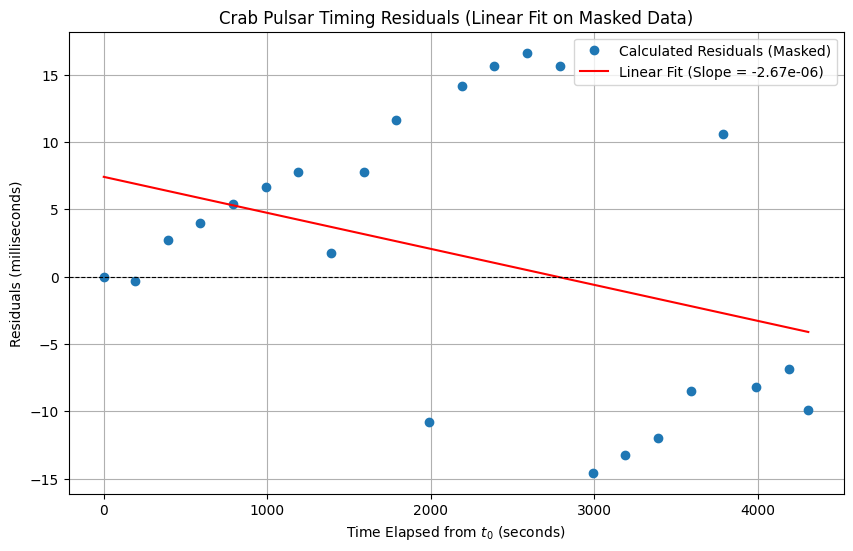

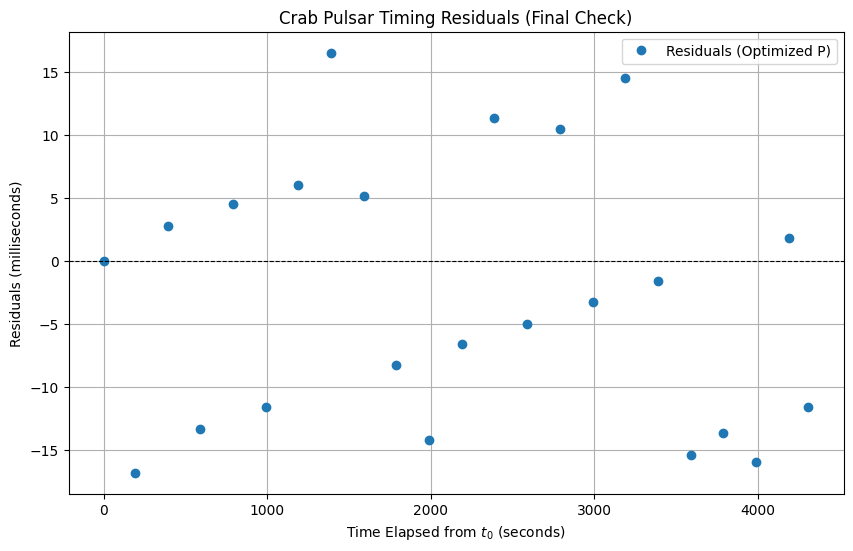

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy.optimize as opt

# # =======================================================
# # !!! PLACEHOLDER DATA: REPLACE WITH YOUR ACTUAL DATA !!!
# # =======================================================

# # Simulate corrected_time_mjd to make the code runnable
# # Assuming 'corrected_time_mjd' is an array of MJD times
# #corrected_time_mjd = np.array([55000.0, 55001.0, 55002.0, 55003.0, 55004.0, 55005.0])

# # Define values to omit (e.g., the second and fourth data points in time_elapsed)
# # You will need to calculate these values based on the MJD differences from your actual data
# # or use indices/conditions based on your actual data properties.
# # For this example, let's omit the times corresponding to days 55001.0 and 55003.0 MJD.
# # The corresponding time_elapsed (seconds) for these points are 86400.0 and 259200.0
# # (These are just examples; change them to the specific bad values you need to exclude)
# VALUES_TO_OMIT_SECONDS = np.array([1390.10063808,  1990.16269022, 3790.30622465])

# # =======================================================
# # Constants
# SECONDS_PER_DAY = 86400.0

# # Initial model period estimate (in seconds)
# period_guess = 0.033847063 # seconds

# # Reference (The first corrected TOA)
# t_0_mjd = corrected_time_mjd[0]

# # Calculate time difference (t - t0) in MJD days
# delta_t_days = corrected_time_mjd - t_0_mjd

# # Convert time difference to seconds
# delta_t_seconds = delta_t_days * SECONDS_PER_DAY
# time_elapsed = delta_t_seconds

# print("Time elapsed (s):", time_elapsed)

# # --- MASKING LOGIC IMPLEMENTED HERE ---
# ## 🎭 Create the Mask
# # True indicates values to KEEP (i.e., not in the values_to_omit list)
# mask_to_keep = ~np.isin(time_elapsed, VALUES_TO_OMIT_SECONDS)

# # Apply the mask to the time array for use in fitting functions
# time_elapsed_masked = time_elapsed[mask_to_keep]
# delta_t_seconds_masked = delta_t_seconds[mask_to_keep] # Use this in chisqfunc

# print(f"\nMask applied. Number of points kept: {np.sum(mask_to_keep)} out of {len(time_elapsed)}")
# print(f"Masked time_elapsed (s): {time_elapsed_masked}")
# # ------------------------------------

# # Calculate the EXPECTED number of rotations (N) based on the model
# N = delta_t_seconds / period_guess
# N_integer = np.round(N)
# N_fraction = N - N_integer

# # Calculate the RESIDUAL in TIME (seconds)
# residuals = N_fraction * period_guess
# print("residuals (full array):", residuals)

# ## 🎭 Mask the Residuals
# residuals_masked = residuals[mask_to_keep]
# print("residuals (masked array):", residuals_masked)

# # Linear fitting - Uses the MASKED arrays
# # We fit Residuals (Y) vs. Time Elapsed (X)
# (slope_m, intercept_c) = np.polyfit(time_elapsed_masked, residuals_masked, 1)

# # --- Optimization Functions (Modified to use masked data) ---
# ###
# def residual_calc(period_guess):
#      # Use the MASKED time array for the calculation
#      N = delta_t_seconds_masked / period_guess
#      N_int = np.round(N)
#      frac = N - N_int
#      return frac * period_guess

# def chisqfunc(period_guess):
#      res = residual_calc(period_guess)
#      # We are minimizing the sum of squared residuals (equivalent to Chi-Squared if weights/errors are 1)
#      return np.sum((res)**2)

# # Run Optimization
# x0 = np.array([period_guess])
# result = opt.minimize(chisqfunc, x0)
# print("\n--- Optimization Result (Masked Data) ---")
# print(result)

# # --- 6. Plotting ---
# # Create the best-fit line for plotting (uses the FULL time_elapsed array for the plot line)
# # You might choose to only plot the line across the masked data range, but here we plot it across the full range
# fit_line = slope_m * time_elapsed + intercept_c

# plt.figure(figsize=(10, 6))
# # Plot only the MASKED residuals
# plt.plot(time_elapsed_masked, residuals_masked * 1000, 'o', label='Calculated Residuals (Masked)')
# plt.plot(time_elapsed, fit_line * 1000, 'r-', label=f'Linear Fit (Slope = {slope_m:.2e})')
# plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

# plt.xlabel('Time Elapsed from $t_0$ (seconds)')
# plt.ylabel('Residuals (milliseconds)')
# plt.title(f'Crab Pulsar Timing Residuals (Linear Fit on Masked Data)')
# plt.legend()
# plt.grid(True)
# plt.show()

# # ==================== Check the result (Second Run) =================

# # Use the fitted period from the minimization
# period_guess_optimized = 3.385e-02 #result.x[0]

# # Recalculate residuals using the optimized period on the FULL dataset
# N_optimized = delta_t_seconds / period_guess_optimized
# N_integer_optimized = np.round(N_optimized)
# N_fraction_optimized = N_optimized - N_integer_optimized
# residuals_optimized = N_fraction_optimized * period_guess_optimized

# # The linear fit here is generally not useful after a successful period minimization,
# # as the residuals should be flat (zero slope) with respect to time.
# (slope_m_check, intercept_c_check) = np.polyfit(time_elapsed, residuals_optimized, 1)

# # --- 6. Plotting ---
# plt.figure(figsize=(10, 6))
# # Plot the new residuals (full array)
# plt.plot(time_elapsed, residuals_optimized * 1000, 'o', label='Residuals (Optimized P)')
# plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

# plt.xlabel('Time Elapsed from $t_0$ (seconds)')
# plt.ylabel('Residuals (milliseconds)')
# plt.title(f'Crab Pulsar Timing Residuals (Final Check)')
# plt.legend()
# plt.grid(True)
# plt.show()